In [ ]:
import sys
import os
import time

import mlflow
import numpy as np
import pandas as pd
import catboost as cb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score as auc

sys.path.append(os.path.abspath("../src"))
os.environ["MLFLOW_TRACKING_URI"] = "http://127.0.0.1:5000"

In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
from Preprocessing import Preprocessor
from postgres_connection import connection, all_tables
from utils import create_submission

In [4]:
start_time = time.time()

# Data loading

In [5]:
tables = all_tables()
display(tables)

,table_name
0,application_train
1,previous_application
2,credit_card_balance
3,bureau_balance
4,application_test
5,bureau
6,homecredit_columns_description
7,installments_payments
8,sample_submission
9,pos_cash_balance


In [6]:
df_description = connection("dwh.homecredit_columns_description;")
df_description.head(10)

,column1,table,row,description,special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,
5,8,application_{train|test}.csv,FLAG_OWN_REALTY,Flag if client owns a house or flat,
6,9,application_{train|test}.csv,CNT_CHILDREN,Number of children the client has,
7,10,application_{train|test}.csv,AMT_INCOME_TOTAL,Income of the client,
8,11,application_{train|test}.csv,AMT_CREDIT,Credit amount of the loan,
9,12,application_{train|test}.csv,AMT_ANNUITY,Loan annuity,


In [7]:
df_train = connection("dwh.application_train;")
df_train.head()

,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,...,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
0,347635,0,Cash loans,F,N,N,0,135000.0,108000.0,11587.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0
1,347636,1,Cash loans,F,N,Y,0,135000.0,297130.5,18306.0,...,0,0,0,0,0.0,1.0,0.0,0.0,0.0,3.0
2,347637,0,Cash loans,F,N,Y,0,126000.0,808650.0,23773.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
3,347638,0,Cash loans,F,N,Y,2,112500.0,337500.0,26793.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,3.0
4,347640,0,Cash loans,F,N,N,0,112500.0,585000.0,31756.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0


In [8]:
description = df_train.describe().T
description['nans'] = df_train.shape[0] - description["count"]
description = description.T
description.T.describe()

,count,mean,std,min,25%,50%,75%,max,nans
count,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,1.060000e+02,106.000000
mean,228378.037736,15569.773160,12055.477374,1259.136938,7461.422425,13097.637775,19582.492814,1.190315e+06,79132.962264
std,88679.981781,83608.079267,59368.148164,12264.697714,40597.693041,72241.697770,109202.512379,1.136914e+07,88679.981781
min,92646.000000,-16036.995067,0.001803,-25229.000000,-19682.000000,-15750.000000,-12413.000000,-7.489000e+03,0.000000
25%,143620.000000,0.016575,0.074842,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
50%,306490.000000,0.101365,0.112163,0.000000,0.000000,0.011225,0.099200,1.000000e+00,1021.000000
75%,307511.000000,0.480860,0.384164,0.000000,0.083300,0.197900,0.667697,1.000000e+00,163891.000000
max,307511.000000,599025.999706,402490.776996,100002.000000,270000.000000,513531.000000,808650.000000,1.170000e+08,214865.000000


In [9]:
aux = ['sk_id_curr']  # Вспомогательный список с колонной, которую нужно исключить
target = ['target']  # Целевая переменная
categ = [col for col in df_train.columns if col not in (aux + target) and df_train[col].nunique() <= 7] + \
        [col for col in df_train.columns if col not in (aux + target) and df_train[col].dtypes == np.dtype('O')]
categ = list(set(categ))

nums = [col for col in df_train.columns if col not in (categ + target + aux)]

# Вывод количества категориальных и числовых переменных
print(f"Список категориальных переменных: {len(categ)}")
print(f"Список числовых переменных: {len(nums)}")

Список категориальных переменных: 51
Список числовых переменных: 69


In [10]:
col_nunique = {col: df_train[col].nunique() for col in df_train.columns if col not in aux + target}
col_nunique


{'name_contract_type': 2,
 'code_gender': 3,
 'flag_own_car': 2,
 'flag_own_realty': 2,
 'cnt_children': 15,
 'amt_income_total': 2548,
 'amt_credit': 5603,
 'amt_annuity': 13672,
 'amt_goods_price': 1002,
 'name_type_suite': 8,
 'name_income_type': 8,
 'name_education_type': 5,
 'name_family_status': 6,
 'name_housing_type': 6,
 'region_population_relative': 81,
 'days_birth': 17460,
 'days_employed': 12574,
 'days_registration': 15688,
 'days_id_publish': 6168,
 'own_car_age': 62,
 'flag_mobil': 2,
 'flag_emp_phone': 2,
 'flag_work_phone': 2,
 'flag_cont_mobile': 2,
 'flag_phone': 2,
 'flag_email': 2,
 'occupation_type': 19,
 'cnt_fam_members': 17,
 'region_rating_client': 3,
 'region_rating_client_w_city': 3,
 'weekday_appr_process_start': 7,
 'hour_appr_process_start': 24,
 'reg_region_not_live_region': 2,
 'reg_region_not_work_region': 2,
 'live_region_not_work_region': 2,
 'reg_city_not_live_city': 2,
 'reg_city_not_work_city': 2,
 'live_city_not_work_city': 2,
 'organization_typ

In [11]:
df_train['code_gender'].value_counts()

code_gender
F      202448
M      105059
XNA         4
Name: count, dtype: int64

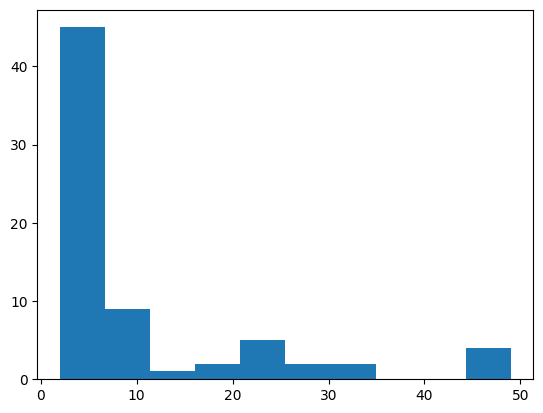

In [12]:
plt.hist(list(filter(lambda x: x <= 50, col_nunique.values())))
plt.show()


# Create Dataset


In [13]:
prep = Preprocessor()
prep_df_train = prep.fit_predict(df_train)
prep_df_train

,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,...,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
0,347635,0,Cash loans,F,N,N,0,135000.0,108000.0,11587.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0
1,347636,1,Cash loans,F,N,Y,0,135000.0,297130.5,18306.0,...,0,0,0,0,0.0,1.0,0.0,0.0,0.0,3.0
2,347637,0,Cash loans,F,N,Y,0,126000.0,808650.0,23773.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
3,347638,0,Cash loans,F,N,Y,2,112500.0,337500.0,26793.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,3.0
4,347640,0,Cash loans,F,N,N,0,112500.0,585000.0,31756.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,347630,0,Cash loans,M,Y,Y,2,157500.0,523237.5,24520.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
307507,347631,0,Cash loans,F,N,Y,0,180000.0,370629.0,13441.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
307508,347632,0,Cash loans,M,Y,N,0,270000.0,225000.0,22252.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
307509,347633,0,Cash loans,M,Y,Y,0,360000.0,1305000.0,38155.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,0.0


In [14]:
X_train, X_test = train_test_split(prep_df_train, test_size=0.25, stratify=df_train['target'])
X_train


,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,...,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
74783,434231,1,Cash loans,F,N,N,0,139500.0,675000.0,53329.5,...,0,0,0,0,0.0,0.0,0.0,0.0,2.0,2.0
137503,150602,0,Cash loans,F,N,Y,0,112500.0,1006920.0,40063.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,6.0
92704,455027,0,Cash loans,F,N,N,0,90000.0,1125000.0,32895.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
268811,302817,0,Cash loans,M,N,Y,2,225000.0,469147.5,25578.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0
269683,303820,0,Revolving loans,F,N,N,0,135000.0,270000.0,13500.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88061,449628,0,Cash loans,M,N,Y,2,225000.0,497520.0,53712.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,2.0
277287,312690,0,Cash loans,F,N,Y,2,81000.0,247275.0,17586.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
33022,385547,0,Cash loans,M,Y,Y,2,180000.0,284400.0,19134.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
119378,129746,0,Revolving loans,F,N,Y,0,247500.0,675000.0,33750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,2.0,3.0


In [15]:
train_pool = cb.Pool(
    X_train[categ + nums],  # Тренировочные данные (категориальные + числовые признаки)
    label=X_train[target[0]],  # Целевая переменная для обучения
    cat_features=categ  # Список категориальных признаков
)

test_pool = cb.Pool(
    X_test[categ + nums],  # Тестовые данные (категориальные + числовые признаки)
    label=X_test[target[0]],  # Целевая переменная для тестирования
    cat_features=categ  # Список категориальных признаков
)


# Learn Model

In [16]:

clf = cb.CatBoostClassifier(
    iterations=1000,  # Количество итераций
    verbose=20,       # Вывод каждые 20 итераций
    eval_metric='AUC' # Метрика оценки качества
)
mlflow.set_experiment("rishon")

mlflow.autolog()
with mlflow.start_run():
    # Обучение модели на тренировочных данных
    clf.fit(train_pool, plot=True, verbose_eval=True)

2025/04/02 21:41:28 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Learning rate set to 0.105172
0:	total: 244ms	remaining: 4m 3s
1:	total: 409ms	remaining: 3m 24s
2:	total: 596ms	remaining: 3m 18s
3:	total: 799ms	remaining: 3m 18s
4:	total: 975ms	remaining: 3m 14s
5:	total: 1.21s	remaining: 3m 20s
6:	total: 1.42s	remaining: 3m 20s
7:	total: 1.57s	remaining: 3m 14s
8:	total: 1.72s	remaining: 3m 9s
9:	total: 2s	remaining: 3m 18s
10:	total: 2.17s	remaining: 3m 14s
11:	total: 2.34s	remaining: 3m 12s
12:	total: 2.49s	remaining: 3m 9s
13:	total: 2.62s	remaining: 3m 4s
14:	total: 2.83s	remaining: 3m 6s
15:	total: 3s	remaining: 3m 4s
16:	total: 3.26s	remaining: 3m 8s
17:	total: 3.44s	remaining: 3m 7s
18:	total: 3.55s	remaining: 3m 3s
19:	total: 3.72s	remaining: 3m 2s
20:	total: 3.86s	remaining: 2m 59s
21:	total: 3.99s	remaining: 2m 57s
22:	total: 4.17s	remaining: 2m 57s
23:	total: 4.34s	remaining: 2m 56s
24:	total: 4.49s	remaining: 2m 55s
25:	total: 4.66s	remaining: 2m 54s
26:	total: 4.78s	remaining: 2m 52s
27:	total: 4.91s	remaining: 2m 50s
28:	total: 5.11s

In [17]:
#mlflow.log_metric("auc_train", auc(X_train[prep.target[0]], clf.predict_proba(train_pool)[:, 1]))
#mlflow.log_metric("auc_test", auc(X_test[prep.target[0]], clf.predict_proba(test_pool)[:, 1]))
#mlflow.catboost.log_model(clf, "model")


In [18]:
mlflow.end_run()

In [19]:
X_train.columns = map(str.lower, X_train.columns)  # Посмотрите точное написание всех колонок
X_test.columns = map(str.lower, X_test.columns) 

In [20]:
# Оценка качества на тренировочных данных
print(f'Train: {auc(X_train[prep.target[0]], clf.predict_proba(train_pool)[:, 1])}')

# Оценка качества на тестовых данных
print(f'Test: {auc(X_test[prep.target[0]], clf.predict_proba(test_pool)[:, 1])}')

Train: 0.8218637869548223
Test: 0.76035866418536


In [21]:
#mlflow.log_metric("train_auc", clf.score(X_train, X_train['target']))

# Submit

In [23]:
df_test = connection('dwh.application_test;')
prep_test = prep.fit_predict(df_test)
prep_test.head()

,sk_id_curr,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,...,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,nan,nan,nan,nan,NaN,NaN


In [24]:
prep_pool = cb.Pool(
    prep_test[categ + nums],
    cat_features=categ
)
prediction = clf.predict_proba(prep_pool)[:, 1]

In [25]:
create_submission(connection('dwh.sample_submission;'), pd.Series(prediction))

submissions/sub_2025-04-02 21:45:11.032092.csv


,sk_id_curr,target
0,100001,0.042684
1,100005,0.144830
2,100013,0.016625
3,100028,0.040572
4,100038,0.183815
...,...,...
48739,456221,0.026359
48740,456222,0.100887
48741,456223,0.027967
48742,456224,0.080083


In [26]:
end_time = time.time()
print(f"Время работы: {end_time - start_time} c")


Время работы: 258.2979278564453 c
